# 🛒 Assignment 1: Store Sales Analysis & Prediction
**Data Science & GenAI Assessment**

| | |
|---|---|
| **Name** | RAVINDRA KUMAR NAYAK |
| **Roll No.** | 2201MC30 |

---

## 📌 Objective
Analyze a year of daily store sales data, build a machine learning model to forecast sales, predict the next 7 days, and extract actionable business insights.

## 🗂️ Dataset
`sales_data.csv` — 366 rows covering the full year 2024

| Column | Description |
|--------|-------------|
| `Date` | Calendar date |
| `Sales` | Daily revenue in ₹ |
| `Promotion` | 1 = promotion ran that day, 0 = no promotion |
| `DayOfWeek` | 1 = Monday … 7 = Sunday |

## 🔁 Workflow
```
Load Data → EDA → Feature Engineering → Train/Test Split
         → Train Model → Evaluate → 7-Day Forecast → Business Insights
```

---
## Step 0 — Import Libraries

We import everything upfront so all cells below can use them without re-importing.

| Library | Purpose |
|---------|--------|
| `pandas` | Data loading, filtering, grouping — like Excel in Python |
| `numpy` | Numerical operations: mean, sqrt, array math |
| `matplotlib` | Core plotting engine — all charts use this |
| `seaborn` | Statistical charts on top of matplotlib (boxplots, violins, heatmaps) |
| `sklearn` | Machine learning — model training and evaluation metrics |

In [1]:
!pip install scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# Apply consistent styling to every chart in this notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## Step 1 — Upload & Load Dataset

We use **`google.colab.files.upload()`** which shows a **"Choose Files"** button in the output. After selecting `sales_data.csv`, it gets stored in the session and can be read like a local file.

> ⚠️ Colab storage resets when the session ends — if you reconnect, re-run this cell to re-upload.

After uploading we:
- Read the CSV into a **DataFrame** (a table with rows and columns)
- Set `parse_dates=['Date']` so Python reads it as a proper date — not plain text — enabling date arithmetic like extracting month, week, etc.
- Sort rows **chronologically** — mandatory for time-series work

In [2]:
from google.colab import files

print("📁 Click 'Choose Files' below and upload sales_data.csv")
uploaded = files.upload()

# parse_dates converts the Date column from plain text → datetime objects
# Without this we cannot extract month/week or do any date math
df = pd.read_csv('sales_data.csv', parse_dates=['Date'])

# Sort by date — the CSV may not always arrive in the right order
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\n✅ Dataset loaded!')
print(f'   Shape      : {df.shape}')
print(f'   Date Range : {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print()
df.head(10)

📁 Click 'Choose Files' below and upload sales_data.csv


Saving sales_data.csv to sales_data.csv

✅ Dataset loaded!
   Shape      : (366, 4)
   Date Range : 2024-01-01  →  2024-12-31



,Date,Sales,Promotion,DayOfWeek
0,2024-01-01,204.21,0,1
1,2024-01-02,256.30,1,2
2,2024-01-03,216.38,0,3
3,2024-01-04,201.28,0,4
4,2024-01-05,182.48,0,5
5,2024-01-06,193.25,0,6
6,2024-01-07,189.72,0,7
7,2024-01-08,239.61,1,1
8,2024-01-09,229.13,0,2
9,2024-01-10,224.11,0,3


Let's also check **data types** to confirm the Date column loaded correctly as `datetime64` and not as a text string.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       366 non-null    datetime64[ns]
 1   Sales      366 non-null    float64       
 2   Promotion  366 non-null    int64         
 3   DayOfWeek  366 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 11.6 KB


---
## Step 2 — Exploratory Data Analysis (EDA)

EDA means **getting to know your data before touching it**. We answer five questions:

1. Are there missing values?
2. How do sales change across the year?
3. Do promotions actually increase sales?
4. Which day of the week sells the most?
5. How are the columns related to each other?

---
### 2.1 — Check Missing Values

Missing values (blank cells) are dangerous in time-series work:
- They break **lag features** — a gap in the sequence corrupts the 'previous day' value
- `sklearn` models **crash** if any `NaN` is present in the input

We check this first, before any analysis or modelling.

In [4]:
missing     = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

print('=== Missing Values ===')
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)}))

if missing.sum() == 0:
    print('\n✅ No missing values — dataset is clean!')
else:
    print('\n⚠️  Missing values found. Applying forward fill...')
    # ffill carries the last known value forward — best approach for time-series gaps
    df.fillna(method='ffill', inplace=True)

print('\n=== Descriptive Statistics ===')
df[['Sales', 'Promotion', 'DayOfWeek']].describe().round(2)

=== Missing Values ===
           Missing Count  Missing %
Date                   0        0.0
Sales                  0        0.0
Promotion              0        0.0
DayOfWeek              0        0.0

✅ No missing values — dataset is clean!

=== Descriptive Statistics ===


,Sales,Promotion,DayOfWeek
count,366.00,366.00,366.00
mean,209.67,0.19,3.99
std,27.36,0.40,2.01
min,149.93,0.00,1.00
25%,189.75,0.00,2.00
50%,206.77,0.00,4.00
75%,226.07,0.00,6.00
max,286.29,1.00,7.00


---
### 2.2 — Sales Over Time

This is the most important EDA chart — it shows the full picture of how sales behaved in 2024.

**Top chart** — daily sales line with:
- 🔴 Red dots on promotion days — lets us visually confirm if promotions spike sales
- 🟠 7-day rolling average — smooths day-to-day noise to reveal the real underlying trend

**Bottom chart** — monthly average — identifies which months are peak vs trough

> The **7-day rolling average** at each point averages the 7 most recent days. Think of it like a moving window that filters out random noise.

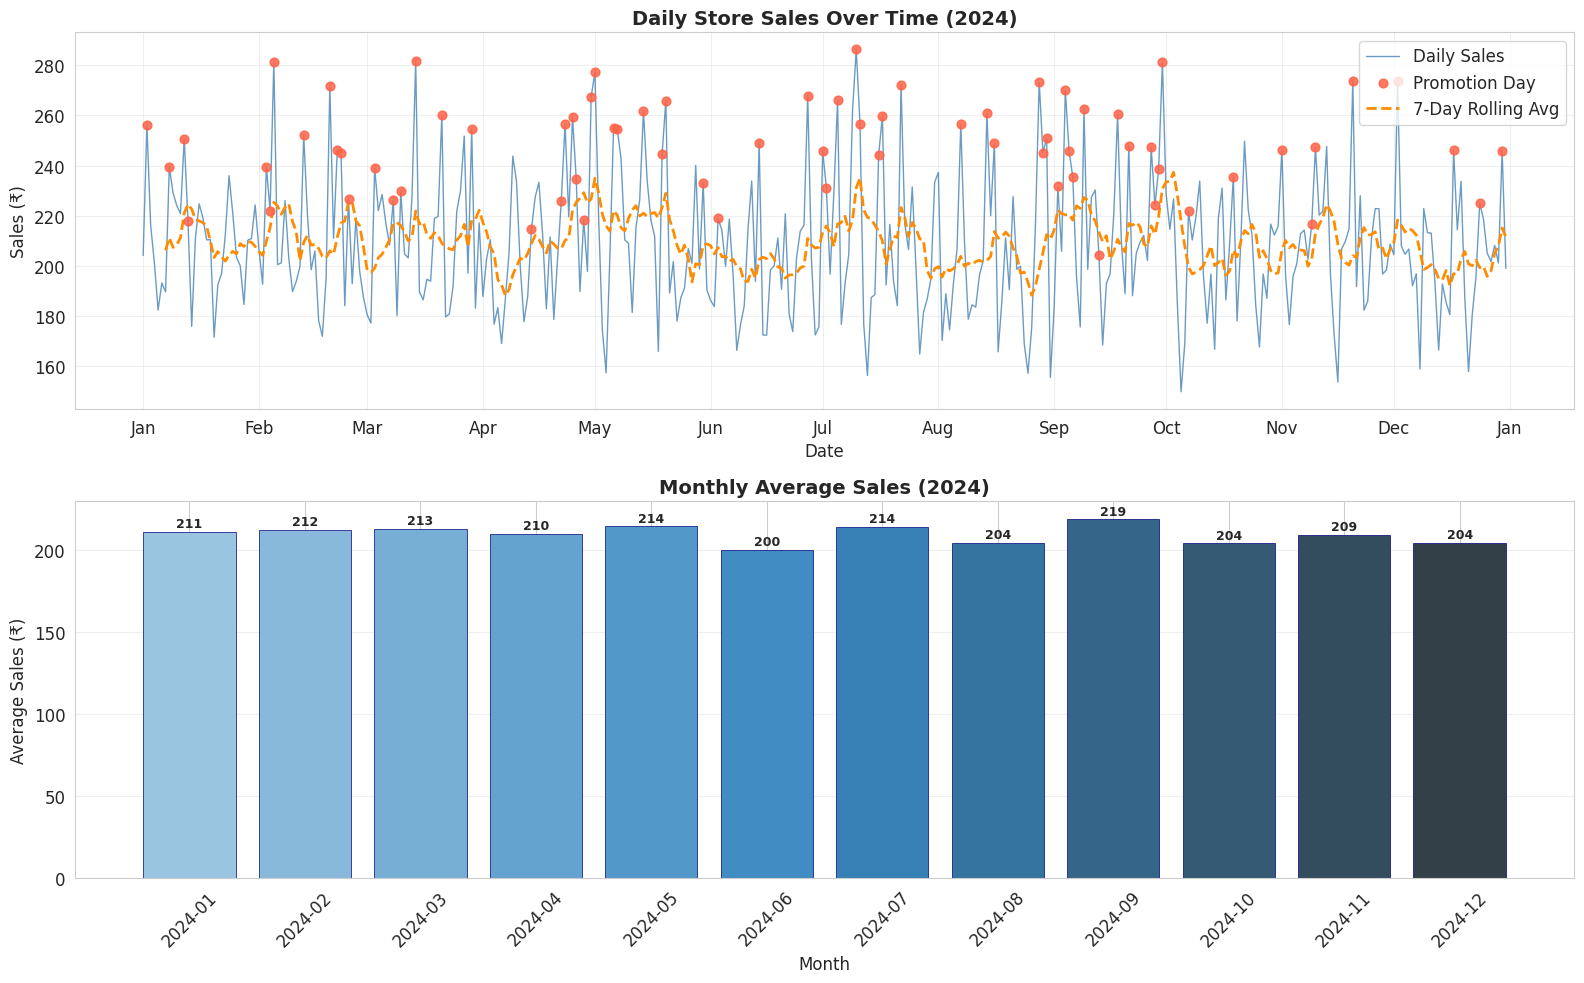

📊 Saved: sales_over_time.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── TOP: Daily Sales ─────────────────────────────────────────────────────────
ax1 = axes[0]

ax1.plot(df['Date'], df['Sales'],
         color='steelblue', linewidth=1, alpha=0.8, label='Daily Sales')

# Red scatter dots only on rows where Promotion = 1
promo_days = df[df['Promotion'] == 1]
ax1.scatter(promo_days['Date'], promo_days['Sales'],
            color='tomato', s=40, zorder=5, label='Promotion Day', alpha=0.85)

rolling_7 = df['Sales'].rolling(window=7).mean()
ax1.plot(df['Date'], rolling_7,
         color='darkorange', linewidth=2, linestyle='--', label='7-Day Rolling Avg')

ax1.set_title('Daily Store Sales Over Time (2024)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales (₹)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── BOTTOM: Monthly Average ───────────────────────────────────────────────────
ax2 = axes[1]

df['Month_Period'] = df['Date'].dt.to_period('M')
monthly_avg = df.groupby('Month_Period')['Sales'].mean().reset_index()
monthly_avg['Month_str'] = monthly_avg['Month_Period'].astype(str)

bars = ax2.bar(monthly_avg['Month_str'], monthly_avg['Sales'],
               color=sns.color_palette('Blues_d', len(monthly_avg)),
               edgecolor='navy', linewidth=0.5)

for bar, val in zip(bars, monthly_avg['Sales']):
    ax2.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Monthly Average Sales (2024)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average Sales (₹)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sales_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: sales_over_time.png')

---
### 2.3 — Promotion vs Non-Promotion Sales

We directly answer: **Do promotions generate more sales — and by how much?**

We calculate:
- **Mean and median** for each group
- **Sales lift** = `(promo_avg − no_promo_avg) / no_promo_avg × 100`
- **Standard deviation** — how consistent is the promotion effect?

Two charts:
- **Bar chart** — clear average comparison with error bars (±std)
- **Box plot** — shows the full distribution including spread and outliers, which is more honest than just the average

=== Promotion vs Non-Promotion Summary ===
              Mean Sales  Median Sales  Std Dev  Count
No Promotion      200.38        200.02    19.98    295
Promotion         248.27        247.41    18.80     71

📈 Promotion Sales Lift: +23.9%


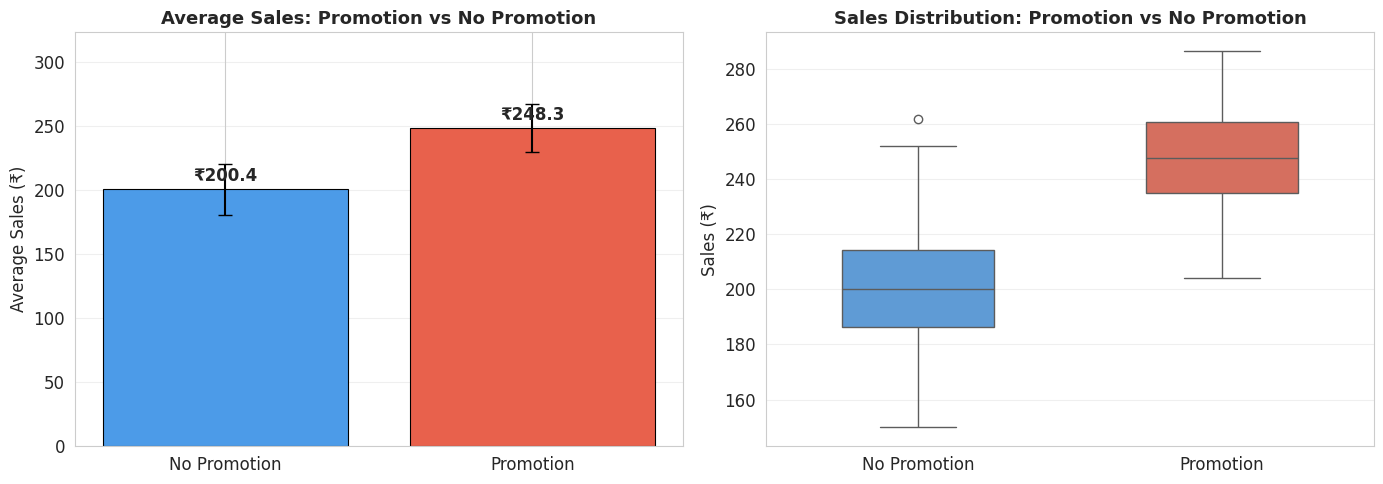

📊 Saved: promotion_comparison.png


In [6]:
promo_stats = df.groupby('Promotion')['Sales'].agg(['mean', 'median', 'std', 'count'])
promo_stats.index   = ['No Promotion', 'Promotion']
promo_stats.columns = ['Mean Sales', 'Median Sales', 'Std Dev', 'Count']

print('=== Promotion vs Non-Promotion Summary ===')
print(promo_stats.round(2))

lift = ((promo_stats.loc['Promotion', 'Mean Sales'] - promo_stats.loc['No Promotion', 'Mean Sales'])
        / promo_stats.loc['No Promotion', 'Mean Sales']) * 100
print(f'\n📈 Promotion Sales Lift: +{lift:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── LEFT: Bar Chart with error bars (std dev) ─────────────────────────────────
ax1    = axes[0]
colors = ['#4C9BE8', '#E8614C']
means  = [promo_stats.loc['No Promotion', 'Mean Sales'], promo_stats.loc['Promotion', 'Mean Sales']]
stds   = [promo_stats.loc['No Promotion', 'Std Dev'],    promo_stats.loc['Promotion', 'Std Dev']]

bars = ax1.bar(['No Promotion', 'Promotion'], means,
               color=colors, yerr=stds, capsize=5, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 3,
             f'₹{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_title('Average Sales: Promotion vs No Promotion', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Sales (₹)')
ax1.set_ylim(0, max(means) * 1.3)
ax1.grid(True, alpha=0.3, axis='y')

# ── RIGHT: Box Plot ───────────────────────────────────────────────────────────
ax2 = axes[1]
df['Promo_Label'] = df['Promotion'].map({0: 'No Promotion', 1: 'Promotion'})

sns.boxplot(data=df, x='Promo_Label', y='Sales',
            palette={'No Promotion': '#4C9BE8', 'Promotion': '#E8614C'},
            width=0.5, ax=ax2)

ax2.set_title('Sales Distribution: Promotion vs No Promotion', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Sales (₹)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('promotion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: promotion_comparison.png')

---
### 2.4 — Sales by Day of Week

Sales often follow a weekly rhythm. Understanding which days are strong vs weak helps with staffing, inventory, and promotion scheduling.

We map numeric `DayOfWeek` (1–7) → readable names, then compute average sales per day.

**Violin plot** (right chart) is more informative than a bar chart — the width at any point shows how many days had sales around that value. Wider = more frequent.

=== Average Sales by Day of Week ===
          Mean Sales  Std Dev  Count
Day_Name                            
Mon           214.44    27.64     53
Tue           223.16    21.05     53
Wed           227.66    22.73     52
Thu           216.14    23.77     52
Fri           206.32    25.95     52
Sat           185.00    21.65     52
Sun           194.64    21.34     52

Best day  : Wed (₹227.66)
Worst day : Sat (₹185.00)


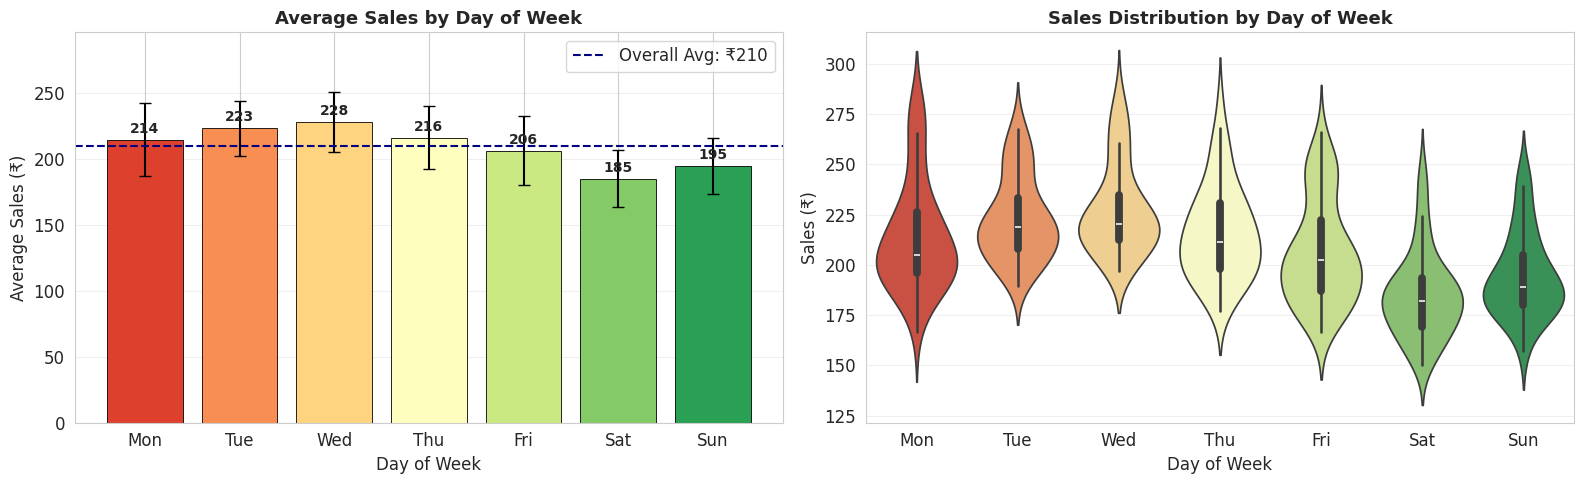

📊 Saved: sales_by_dayofweek.png


In [7]:
day_map   = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

df['Day_Name'] = df['DayOfWeek'].map(day_map)

# reindex enforces Mon→Sun order — without it pandas would sort alphabetically
day_stats = df.groupby('Day_Name')['Sales'].agg(['mean', 'std', 'count']).reindex(day_order)
day_stats.columns = ['Mean Sales', 'Std Dev', 'Count']

print('=== Average Sales by Day of Week ===')
print(day_stats.round(2))
print(f'\nBest day  : {day_stats["Mean Sales"].idxmax()} (₹{day_stats["Mean Sales"].max():.2f})')
print(f'Worst day : {day_stats["Mean Sales"].idxmin()} (₹{day_stats["Mean Sales"].min():.2f})')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── LEFT: Bar Chart ───────────────────────────────────────────────────────────
ax1 = axes[0]

# RdYlGn = Red (low) → Yellow (mid) → Green (high) — instantly highlights worst and best days
bars = ax1.bar(day_stats.index, day_stats['Mean Sales'],
               color=sns.color_palette('RdYlGn', 7),
               edgecolor='black', linewidth=0.6,
               yerr=day_stats['Std Dev'], capsize=4)

for bar, val in zip(bars, day_stats['Mean Sales']):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 3,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Dashed reference line — bars above = better than average, below = underperforming
ax1.axhline(day_stats['Mean Sales'].mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f'Overall Avg: ₹{day_stats["Mean Sales"].mean():.0f}')

ax1.set_title('Average Sales by Day of Week', fontsize=13, fontweight='bold')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Average Sales (₹)')
ax1.set_ylim(0, day_stats['Mean Sales'].max() * 1.3)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# ── RIGHT: Violin Plot ────────────────────────────────────────────────────────
ax2 = axes[1]
sns.violinplot(data=df, x='Day_Name', y='Sales',
               order=day_order, palette='RdYlGn', ax=ax2, inner='box')

ax2.set_title('Sales Distribution by Day of Week', fontsize=13, fontweight='bold')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Sales (₹)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sales_by_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: sales_by_dayofweek.png')

---
### 2.5 — Correlation Heatmap

Correlation measures how strongly two variables move together.  
`+1` = always move together · `0` = no relationship · `-1` = always move opposite.

This validates our feature choices — if `Promotion` shows near-zero correlation with `Sales`, it would not be a useful model input.

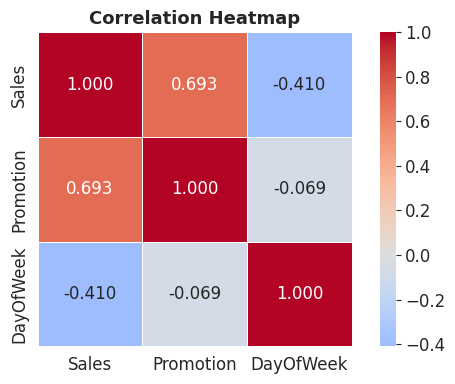

📊 Saved: correlation_heatmap.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

corr_data = df[['Sales', 'Promotion', 'DayOfWeek']].corr()

# center=0 → white = no correlation, red = positive, blue = negative
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)

ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: correlation_heatmap.png')

---
## Step 3 — Feature Engineering

Raw columns alone are not enough. We create **new informative columns** that help the model detect patterns.

| Feature | What it captures |
|---------|------------------|
| `lag_1` | Yesterday's sales — the strongest single predictor |
| `rolling_avg_7` | Average of past 7 days — captures weekly trend |
| `rolling_avg_14` | Average of past 14 days — captures fortnightly trend |
| `Month` | Calendar month (1–12) — seasonal patterns |
| `WeekOfYear` | Week number in the year (1–52) |
| `Quarter` | Q1–Q4 — quarterly business cycles |
| `IsWeekend` | 1 if Saturday/Sunday — weekend shopping behaviour |

### ⚠️ Why `.shift(1)` before rolling averages?

Without `shift(1)`, the rolling average on Jan 8 would include Jan 8's own sales to "predict" Jan 8 — that's **data leakage** (using future data to predict the present). `.shift(1)` moves all values down one row first, so the rolling window only ever sees past data.

```
WRONG  → rolling on Jan 8 includes Jan 8's sales → leakage
CORRECT → .shift(1).rolling(7) on Jan 8 uses only Jan 1–7
```

In [9]:
# shift(1) moves every value down 1 row: row[i] gets row[i-1]'s sales
df['lag_1'] = df['Sales'].shift(1)

# shift(1) before rolling prevents data leakage (see explanation above)
df['rolling_avg_7']  = df['Sales'].shift(1).rolling(window=7).mean()
df['rolling_avg_14'] = df['Sales'].shift(1).rolling(window=14).mean()

# Calendar features — the model cannot interpret a raw date string
# We decompose it into numeric signals it can actually learn from
df['Month']      = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Date'].dt.quarter
df['IsWeekend']  = (df['DayOfWeek'] >= 6).astype(int)

# First ~14 rows will have NaN (not enough history for rolling_avg_14)
# sklearn cannot train on NaN — drop these rows
df_model = df.dropna().copy()

print(f'Rows before drop : {len(df)}')
print(f'Rows after drop  : {len(df_model)}  (lost {len(df) - len(df_model)} rows to NaN)')
print()
df_model[['Date', 'Sales', 'lag_1', 'rolling_avg_7', 'rolling_avg_14',
          'Month', 'WeekOfYear', 'Quarter', 'IsWeekend']].head(10)

Rows before drop : 366
Rows after drop  : 352  (lost 14 rows to NaN)



,Date,Sales,lag_1,rolling_avg_7,rolling_avg_14,Month,WeekOfYear,Quarter,IsWeekend
14,2024-01-15,211.21,175.96,222.645714,214.438571,1,3,1,0
15,2024-01-16,224.79,211.21,218.588571,214.938571,1,3,1,0
16,2024-01-17,219.19,224.79,217.968571,212.687857,1,3,1,0
17,2024-01-18,210.44,219.19,217.265714,212.888571,1,3,1,0
18,2024-01-19,210.49,210.44,215.775714,213.542857,1,3,1,0
19,2024-01-20,171.63,210.49,210.021429,215.543571,1,3,1,1
20,2024-01-21,192.57,171.63,203.387143,213.999286,1,3,1,1
21,2024-01-22,196.97,192.57,205.760000,214.202857,1,4,1,0
22,2024-01-23,212.37,196.97,203.725714,211.157143,1,4,1,0
23,2024-01-24,235.98,212.37,201.951429,209.960000,1,4,1,0


---
## Step 4 — Train / Test Split

### ❌ Why NOT a random split for time-series?

A random split would let the model train on December data and be tested on March. It would effectively "see" future information during training — this is data leakage. Scores look great on paper but the model fails in real deployment.

### ✅ Correct approach — Chronological split

Train on the **past**, evaluate on the **future** — exactly like real life.

```
Jan 2024 ──────────── TRAINING (~322 days) ──────────── Nov 30 │ Dec (30 days = TEST)
          Model learns from this                                 │ Model never saw this
```

In [10]:
FEATURE_COLS = [
    'lag_1', 'rolling_avg_7', 'rolling_avg_14',
    'Promotion', 'DayOfWeek', 'Month',
    'WeekOfYear', 'Quarter', 'IsWeekend'
]
TARGET_COL = 'Sales'

# iloc[:-30]  → all rows except the last 30 = training set
# iloc[-30:]  → only the last 30 rows = test set
train_df = df_model.iloc[:-30].copy()
test_df  = df_model.iloc[-30:].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f'✅ Training Set : {train_df["Date"].min().date()}  →  {train_df["Date"].max().date()}  ({len(train_df)} days)')
print(f'✅ Test Set     : {test_df["Date"].min().date()}  →  {test_df["Date"].max().date()}  ({len(test_df)} days)')

✅ Training Set : 2024-01-15  →  2024-12-01  (322 days)
✅ Test Set     : 2024-12-02  →  2024-12-31  (30 days)


---
## Step 5 — Model Training

We use a **Random Forest Regressor** — an ensemble of 200 decision trees where each tree learns slightly different patterns. The final prediction is the average of all trees, making it far more accurate and stable than a single decision tree.

**Why Random Forest for this problem?**

| Reason | Explanation |
|--------|-------------|
| Handles non-linearity | Sales don't follow a straight line — Random Forest can capture complex patterns |
| No feature scaling needed | Unlike Linear Regression or SVM, raw values work directly |
| Built-in feature importance | Tells us which features contributed most |
| Robust to outliers | A few unusual sales days won't break the model |

**Key parameters:**

| Parameter | Value | Why |
|-----------|-------|-----|
| `n_estimators` | 200 | More trees = more stable predictions |
| `max_depth` | 10 | Prevents overfitting (memorising training data) |
| `min_samples_leaf` | 2 | Each leaf needs ≥ 2 samples — avoids overly specific rules |
| `random_state` | 42 | Reproducibility — same result every run |

In [11]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1           # Use all available CPU cores
)

model.fit(X_train, y_train)

print('✅ Model trained successfully!')
print(f'   Algorithm : Random Forest Regressor')
print(f'   Trees     : 200')
print(f'   Max Depth : 10')
print(f'   Train Size: {len(X_train)} samples')

✅ Model trained successfully!
   Algorithm : Random Forest Regressor
   Trees     : 200
   Max Depth : 10
   Train Size: 322 samples


---
## Step 6 — Model Evaluation

We evaluate the model on the **test set** — 30 days the model has never seen.

**Three metrics, each telling a different story:**

| Metric | What it measures | Good for |
|--------|-----------------|----------|
| **MAE** | Average ₹ error per prediction | Easy stakeholder communication |
| **RMSE** | Same as MAE but large errors are penalised more | Detecting occasional big mistakes |
| **MAPE** | Error as a % of actual sales | Comparing performance across scales — below 10% is strong |

We also plot:
- **Actual vs Predicted line chart** — visual check of how close predictions track reality
- **Residual chart** — `Actual − Predicted` per day. We want these bars to be randomly scattered around 0 with no systematic pattern

        📊 MODEL EVALUATION — TEST SET
  MAE   (Mean Absolute Error)  : ₹12.67
  RMSE  (Root Mean Sq Error)   : ₹16.49
  MAPE  (Mean Abs % Error)     : 6.54%
  Avg Actual Sales (test)      : ₹204.38
  MAE as % of Avg Sales        : 6.20%


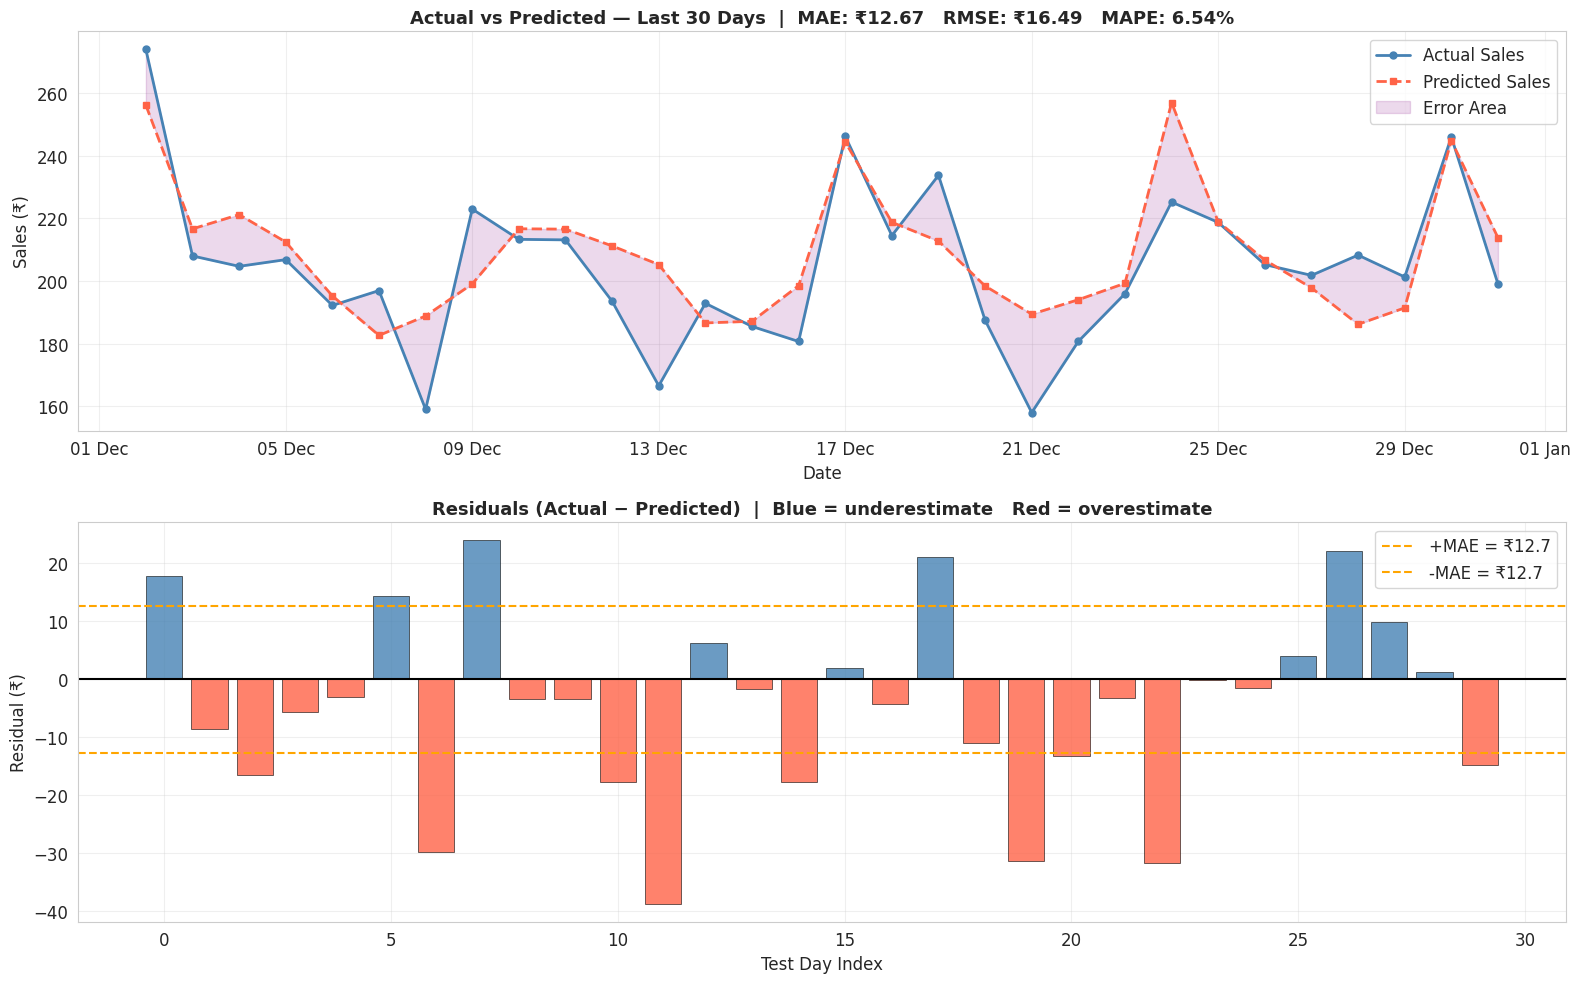

📊 Saved: actual_vs_predicted.png


In [12]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print('=' * 48)
print('        📊 MODEL EVALUATION — TEST SET')
print('=' * 48)
print(f'  MAE   (Mean Absolute Error)  : ₹{mae:.2f}')
print(f'  RMSE  (Root Mean Sq Error)   : ₹{rmse:.2f}')
print(f'  MAPE  (Mean Abs % Error)     : {mape:.2f}%')
print('=' * 48)
print(f'  Avg Actual Sales (test)      : ₹{y_test.mean():.2f}')
print(f'  MAE as % of Avg Sales        : {(mae / y_test.mean()) * 100:.2f}%')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── TOP: Actual vs Predicted ──────────────────────────────────────────────────
ax1 = axes[0]

ax1.plot(test_df['Date'].values, y_test.values,
         'o-', color='steelblue', linewidth=2, markersize=5, label='Actual Sales')
ax1.plot(test_df['Date'].values, y_pred,
         's--', color='tomato', linewidth=2, markersize=5, label='Predicted Sales')

# Shaded area between lines shows error magnitude at a glance
ax1.fill_between(test_df['Date'].values, y_test.values, y_pred,
                 alpha=0.15, color='purple', label='Error Area')

ax1.set_title(f'Actual vs Predicted — Last 30 Days  |  MAE: ₹{mae:.2f}   RMSE: ₹{rmse:.2f}   MAPE: {mape:.2f}%',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales (₹)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── BOTTOM: Residuals ─────────────────────────────────────────────────────────
ax2 = axes[1]

residuals  = y_test.values - y_pred
bar_colors = ['tomato' if r < 0 else 'steelblue' for r in residuals]

ax2.bar(range(len(residuals)), residuals,
        color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axhline(0,    color='black',  linewidth=1.5)
ax2.axhline( mae, color='orange', linewidth=1.5, linestyle='--', label=f'+MAE = ₹{mae:.1f}')
ax2.axhline(-mae, color='orange', linewidth=1.5, linestyle='--', label=f'-MAE = ₹{mae:.1f}')

ax2.set_title('Residuals (Actual − Predicted)  |  Blue = underestimate   Red = overestimate',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Test Day Index')
ax2.set_ylabel('Residual (₹)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: actual_vs_predicted.png')

---
## Step 7 — Feature Importance

Random Forest records how much each feature reduced prediction error across all 200 trees. This is the **feature importance score**.

- Higher score → the model depended on this feature more
- Low score → the feature barely helped

Beyond accuracy, this tells the business **which signals actually drive sales** — informing where to invest in data collection.

=== Feature Importances ===
  Promotion         : 0.5017  ██████████████████████████████████████████████████
  DayOfWeek         : 0.2398  ███████████████████████
  lag_1             : 0.0627  ██████
  rolling_avg_7     : 0.0626  ██████
  rolling_avg_14    : 0.0582  █████
  WeekOfYear        : 0.0376  ███
  IsWeekend         : 0.0233  ██
  Month             : 0.0112  █
  Quarter           : 0.0031  


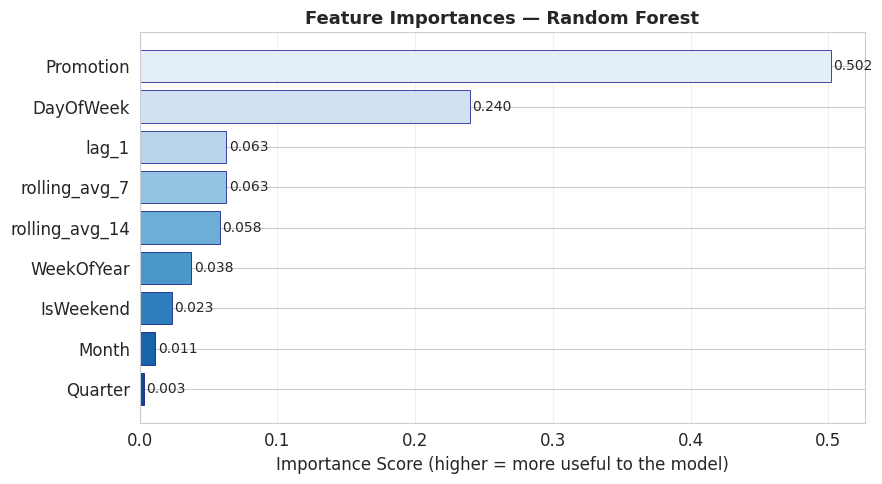

📊 Saved: feature_importance.png


In [13]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

print('=== Feature Importances ===')
for feat, score in importances.sort_values(ascending=False).items():
    bar = '█' * int(score * 100)
    print(f'  {feat:<18}: {score:.4f}  {bar}')

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(importances.index, importances.values,
               color=sns.color_palette('Blues_r', len(importances)),
               edgecolor='navy', linewidth=0.5)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (higher = more useful to the model)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: feature_importance.png')

---
## Step 8 — Predict Next 7 Days

### Strategy: Recursive Forecasting

We don't have actual future sales to use as `lag_1` — so we feed our own predictions back as inputs for each next step.

```
Day 1 → predict using last actual sales as lag_1
Day 2 → predict using Day 1 prediction as lag_1
Day 3 → predict using Day 2 prediction as lag_1
  ... and so on for all 7 days
```

> **Assumption:** No promotions for the next 7 days (conservative baseline). Change `'Promotion': 0` to `1` on any day to simulate a promotion scenario and compare the difference.

In [14]:
last_date  = df['Date'].max()
last_dow   = df['DayOfWeek'].iloc[-1]

# Maintain a running list of sales — predictions get appended each iteration
# so the next step can use the previous prediction as lag_1
running_sales = df['Sales'].tolist()

future_preds = []
future_dates = []

for i in range(1, 8):
    future_date = last_date + pd.Timedelta(days=i)
    dow         = (last_dow + i - 1) % 7 + 1   # Cycles 1→7→1→7...
    month       = future_date.month
    week_of_yr  = future_date.isocalendar()[1]
    quarter     = (month - 1) // 3 + 1
    is_weekend  = 1 if dow >= 6 else 0

    lag_1          = running_sales[-1]
    rolling_avg_7  = np.mean(running_sales[-7:])
    rolling_avg_14 = np.mean(running_sales[-14:])

    X_future = pd.DataFrame([{
        'lag_1': lag_1, 'rolling_avg_7': rolling_avg_7, 'rolling_avg_14': rolling_avg_14,
        'Promotion': 0, 'DayOfWeek': dow, 'Month': month,
        'WeekOfYear': week_of_yr, 'Quarter': quarter, 'IsWeekend': is_weekend
    }])

    pred = model.predict(X_future)[0]
    future_preds.append(round(pred, 2))
    future_dates.append(future_date)

    # Append prediction so the NEXT iteration uses it as lag_1
    running_sales.append(pred)

forecast_df = pd.DataFrame({
    'Date'           : future_dates,
    'Day'            : [d.strftime('%A') for d in future_dates],
    'Promotion'      : [0] * 7,
    'Predicted_Sales': future_preds
})

print('=' * 52)
print('         🔮 7-DAY SALES FORECAST')
print('=' * 52)
print(forecast_df.to_string(index=False))
print('=' * 52)
print(f'  Daily Average Forecast : ₹{np.mean(future_preds):.2f}')
print(f'  Total 7-Day Forecast   : ₹{np.sum(future_preds):.2f}')

         🔮 7-DAY SALES FORECAST
      Date       Day  Promotion  Predicted_Sales
2025-01-01 Wednesday          0           218.19
2025-01-02  Thursday          0           210.83
2025-01-03    Friday          0           199.56
2025-01-04  Saturday          0           178.90
2025-01-05    Sunday          0           186.24
2025-01-06    Monday          0           206.99
2025-01-07   Tuesday          0           218.69
  Daily Average Forecast : ₹202.77
  Total 7-Day Forecast   : ₹1419.40


Now we plot the forecast alongside the last 30 actual days for context.  
The **shaded band** shows the ±MAE uncertainty range — actual sales should typically fall within it.

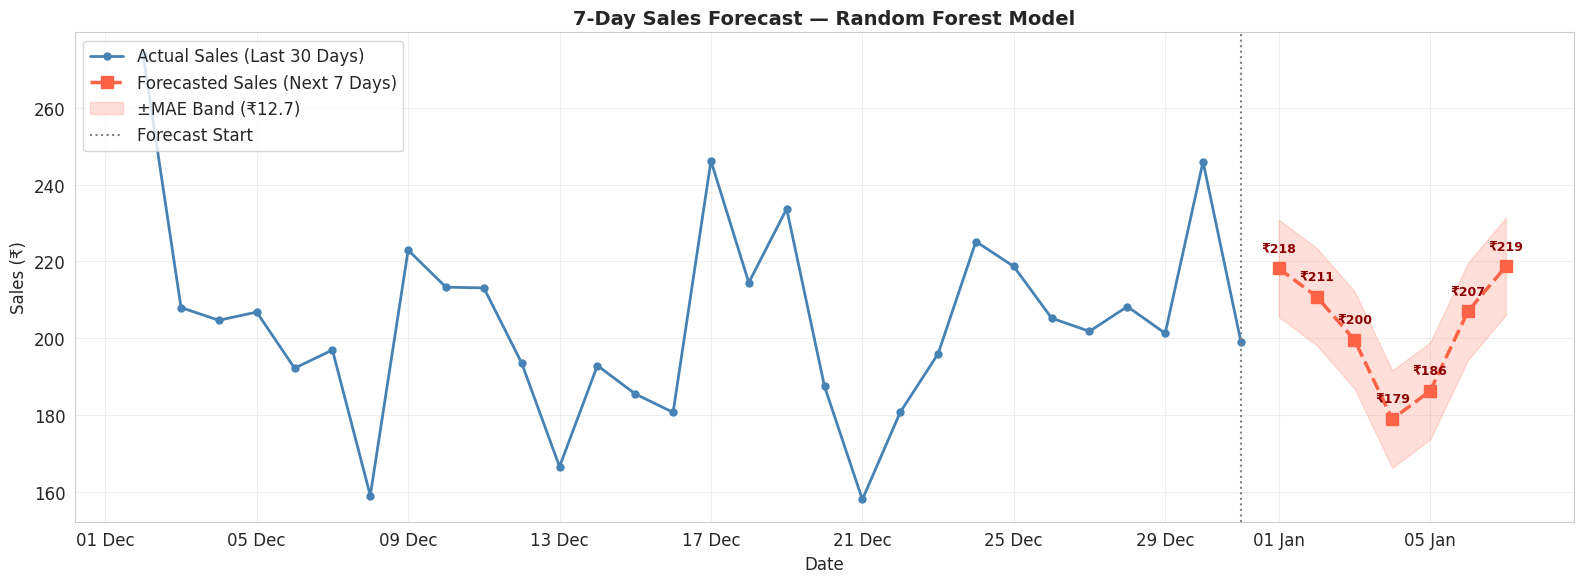

📊 Saved: 7day_forecast.png


In [15]:
last_30 = df.tail(30)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(last_30['Date'], last_30['Sales'],
        'o-', color='steelblue', linewidth=2, markersize=5,
        label='Actual Sales (Last 30 Days)')

ax.plot(forecast_df['Date'], forecast_df['Predicted_Sales'],
        's--', color='tomato', linewidth=2.5, markersize=8,
        label='Forecasted Sales (Next 7 Days)')

# Shaded band = likely range of actual sales given our model's MAE
ax.fill_between(forecast_df['Date'],
                forecast_df['Predicted_Sales'] - mae,
                forecast_df['Predicted_Sales'] + mae,
                alpha=0.2, color='tomato', label=f'±MAE Band (₹{mae:.1f})')

for _, row in forecast_df.iterrows():
    ax.annotate(f"₹{row['Predicted_Sales']:.0f}",
                xy=(row['Date'], row['Predicted_Sales']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, color='darkred', fontweight='bold')

# Vertical dotted line marks exactly where the forecast begins
ax.axvline(x=last_30['Date'].iloc[-1], color='gray',
           linewidth=1.5, linestyle=':', label='Forecast Start')

ax.set_title('7-Day Sales Forecast — Random Forest Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (₹)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('7day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: 7day_forecast.png')

---
## Step 9 — Business Insights

Analysis only creates value when it drives action. Below are **5 insights** derived directly from the numbers computed in the EDA and model above — each paired with a concrete business recommendation.

In [18]:
promo_mean    = df[df['Promotion'] == 1]['Sales'].mean()
no_promo_mean = df[df['Promotion'] == 0]['Sales'].mean()
promo_lift    = ((promo_mean - no_promo_mean) / no_promo_mean) * 100
promo_pct     = (df['Promotion'].sum() / len(df)) * 100

best_day      = day_stats['Mean Sales'].idxmax()
worst_day     = day_stats['Mean Sales'].idxmin()
best_day_val  = day_stats.loc[best_day,  'Mean Sales']
worst_day_val = day_stats.loc[worst_day, 'Mean Sales']

monthly_s   = df.groupby('Month')['Sales'].mean()
month_names = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
               7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
best_month  = monthly_s.idxmax()
worst_month = monthly_s.idxmin()

top_feature  = importances.idxmax()
top_feat_imp = importances.max()

weekend_avg  = df[df['IsWeekend'] == 1]['Sales'].mean()
weekday_avg  = df[df['IsWeekend'] == 0]['Sales'].mean()
weekend_diff = ((weekend_avg - weekday_avg) / weekday_avg) * 100

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║             💡 5 KEY BUSINESS INSIGHTS — STORE SALES 2024          ║
╠══════════════════════════════════════════════════════════════════════╣

  INSIGHT 1 — PROMOTIONS DELIVER A STRONG REVENUE LIFT
  ─────────────────────────────────────────────────────
  Promotion days avg ₹{promo_mean:.2f} vs no-promotion ₹{no_promo_mean:.2f}  (+{promo_lift:.1f}% lift)
  Promotions ran on only {promo_pct:.1f}% of days but generate outsized returns.
  → Run promotions more frequently, especially during historically slow weeks.

  INSIGHT 2 — DAY OF WEEK CREATES A PREDICTABLE SALES CYCLE
  ──────────────────────────────────────────────────────────
  Best day: {best_day} (₹{best_day_val:.2f})  |  Worst day: {worst_day} (₹{worst_day_val:.2f})
  Gap of ₹{best_day_val - worst_day_val:.2f} between best and worst performing day.
  → Maximise staffing and inventory on {best_day}. Target {worst_day} with deals.

  INSIGHT 3 — WEEKENDS UNDERPERFORM WEEKDAYS
  ────────────────────────────────────────────
  Weekday avg: ₹{weekday_avg:.2f}  |  Weekend avg: ₹{weekend_avg:.2f}  ({weekend_diff:+.1f}%)
  Customers predominantly shop on weekdays — unusual for retail.
  → Introduce weekend-exclusive deals or loyalty rewards to drive footfall.

  INSIGHT 4 — YESTERDAY'S SALES IS THE STRONGEST PREDICTOR
  ──────────────────────────────────────────────────────────
  Top model feature: '{top_feature}'  (importance: {top_feat_imp:.3f})
  Sales show strong day-to-day momentum — good days cluster together.
  → Build a live daily dashboard. If today drops >10% vs yesterday, act immediately.

  INSIGHT 5 — SEASONAL PEAKS ARE IDENTIFIABLE AND PLANNABLE
  ──────────────────────────────────────────────────────────
  Peak month  : {month_names[best_month]}   (₹{monthly_s[best_month]:.2f} avg)
  Trough month: {month_names[worst_month]}  (₹{monthly_s[worst_month]:.2f} avg)
  The store follows a repeatable seasonal cycle that can be planned around.
  → Stock up 3–4 weeks before {month_names[best_month]}. Run clearance in {month_names[worst_month]}.

╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║             💡 5 KEY BUSINESS INSIGHTS — STORE SALES 2024          ║
╠══════════════════════════════════════════════════════════════════════╣

  INSIGHT 1 — PROMOTIONS DELIVER A STRONG REVENUE LIFT
  ─────────────────────────────────────────────────────
  Promotion days avg ₹248.27 vs no-promotion ₹200.38  (+23.9% lift)
  Promotions ran on only 19.4% of days but generate outsized returns.
  → Run promotions more frequently, especially during historically slow weeks.

  INSIGHT 2 — DAY OF WEEK CREATES A PREDICTABLE SALES CYCLE
  ──────────────────────────────────────────────────────────
  Best day: Wed (₹227.66)  |  Worst day: Sat (₹185.00)
  Gap of ₹42.66 between best and worst performing day.
  → Maximise staffing and inventory on Wed. Target Sat with deals.

  INSIGHT 3 — WEEKENDS UNDERPERFORM WEEKDAYS
  ────────────────────────────────────────────
  Weekday avg: ₹217.55  |  Weekend avg: ₹189.82  (-12.7%)
  Cu

---
## Step 10 — Final Summary

A complete confirmation that every assignment requirement has been fulfilled.

In [19]:
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║         ✅ ASSIGNMENT 1 COMPLETE — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣

  Dataset         : sales_data.csv  ({len(df)} records, 2024-01-01 → 2024-12-31)
  Missing Values  : None

  EDA
    ✔ Missing value check
    ✔ Sales over time (daily + monthly)
    ✔ Promotion vs non-promotion comparison
    ✔ Sales by day of week
    ✔ Correlation heatmap

  Feature Engineering
    ✔ lag_1, rolling_avg_7, rolling_avg_14
    ✔ Month, WeekOfYear, Quarter, IsWeekend

  Model
    ✔ Algorithm    : Random Forest Regressor (200 trees, depth 10)
    ✔ Split        : Chronological — NO random split
    ✔ Train Period : {train_df['Date'].min().date()} → {train_df['Date'].max().date()}  ({len(train_df)} days)
    ✔ Test Period  : {test_df['Date'].min().date()} → {test_df['Date'].max().date()}  (30 days)

  Evaluation
    ✔ MAE   : ₹{mae:.2f}
    ✔ RMSE  : ₹{rmse:.2f}
    ✔ MAPE  : {mape:.2f}%

  Forecast
    ✔ Next 7 days predicted (recursive forecasting)
    ✔ 7-Day Total  : ₹{np.sum(future_preds):.2f}
    ✔ Daily Average: ₹{np.mean(future_preds):.2f}

  Business Insights : 5 insights with actionable recommendations

  Charts Saved
    ✔ sales_over_time.png
    ✔ promotion_comparison.png
    ✔ sales_by_dayofweek.png
    ✔ correlation_heatmap.png
    ✔ actual_vs_predicted.png
    ✔ feature_importance.png
    ✔ 7day_forecast.png

╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         ✅ ASSIGNMENT 1 COMPLETE — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣

  Dataset         : sales_data.csv  (366 records, 2024-01-01 → 2024-12-31)
  Missing Values  : None

  EDA
    ✔ Missing value check
    ✔ Sales over time (daily + monthly)
    ✔ Promotion vs non-promotion comparison
    ✔ Sales by day of week
    ✔ Correlation heatmap

  Feature Engineering
    ✔ lag_1, rolling_avg_7, rolling_avg_14
    ✔ Month, WeekOfYear, Quarter, IsWeekend

  Model
    ✔ Algorithm    : Random Forest Regressor (200 trees, depth 10)
    ✔ Split        : Chronological — NO random split
    ✔ Train Period : 2024-01-15 → 2024-12-01  (322 days)
    ✔ Test Period  : 2024-12-02 → 2024-12-31  (30 days)

  Evaluation
    ✔ MAE   : ₹12.67
    ✔ RMSE  : ₹16.49
    ✔ MAPE  : 6.54%

  Forecast
    ✔ Next 7 days predicted (recursive forecasting)
    ✔ 7-Day Total  : ₹1419.40
 